# Cancer Diagnosis — Model Training & Comparison
**Models:** Logistic Regression · Decision Tree · Random Forest · XGBoost · SVM · Naive Bayes  
**Strategy:** SMOTE oversampling · Stratified 5-fold CV · Threshold tuning for high sensitivity

## 1. Setup & Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, f1_score,
    accuracy_score, precision_score, recall_score
)
import shap

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

# ── Load & clean ───────────────────────────────────────────────────────────
df = pd.read_csv('../data/raw/cancer_final.csv', encoding='latin-1', sep=';')
df = df.drop(columns=['id'])

def clean_family_hist(v):
    v = str(v).strip().lower()
    if v == 'no':           return 0
    if 'colon' in v:        return 3
    if 'gastric' in v:      return 2
    if v.startswith('yes'): return 1
    return 0

binary_cols = ['sof','diabetes','tenesmus','previous_rt','rectorrhagia','cancer_diagnosis']
for c in binary_cols:
    df[c] = (df[c].str.strip().str.lower() == 'yes').astype(int)

df['sex']                     = (df['sex'].str.strip().str.lower() == 'man').astype(int)
df['digestive_family_history'] = df['digestive_family_history'].apply(clean_family_hist)

FEATURES = ['age','sex','sof','alcohol','tobacco','diabetes',
            'tenesmus','previous_rt','rectorrhagia',
            'intestinal_habit','digestive_family_history']
TARGET   = 'cancer_diagnosis'

X = df[FEATURES]
y = df[TARGET]

# ── Train / Test split (stratified 80/20) ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}')
print(f'Features: {FEATURES}')

Train: (8104, 11)  |  Test: (2027, 11)
Train positive rate: 0.205  |  Test positive rate: 0.205
Features: ['age', 'sex', 'sof', 'alcohol', 'tobacco', 'diabetes', 'tenesmus', 'previous_rt', 'rectorrhagia', 'intestinal_habit', 'digestive_family_history']


## 2. Define Models

In [4]:
smote = SMOTE(random_state=SEED)

# Each model is wrapped in an imbalanced-learn Pipeline:
#   SMOTE (on train folds only) → Scaler → Classifier
models = {
    'Logistic Regression': ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'Decision Tree': ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('clf', DecisionTreeClassifier(max_depth=6, random_state=SEED))
    ]),
    'Random Forest': ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1))
    ]),
    'XGBoost': ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('clf', XGBClassifier(n_estimators=200, learning_rate=0.1,
                              max_depth=5, use_label_encoder=False,
                              eval_metric='logloss', random_state=SEED, n_jobs=-1))
    ]),
    'SVM': ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, kernel='rbf', random_state=SEED))
    ]),
    'Naive Bayes': ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('clf', GaussianNB())
    ]),
}

print('Models defined:')
for name in models:
    print(f'  ✓ {name}')

Models defined:
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest
  ✓ XGBoost
  ✓ SVM
  ✓ Naive Bayes


## 3. Cross-Validation (5-Fold Stratified)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_metrics = ['roc_auc', 'f1', 'recall', 'precision', 'accuracy']

cv_results = {}
print('Running 5-fold cross-validation...\n')
for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=cv_metrics, n_jobs=-1)
    cv_results[name] = {m: scores[f'test_{m}'] for m in cv_metrics}
    print(f'{name:22s}  AUC={scores["test_roc_auc"].mean():.4f} ± {scores["test_roc_auc"].std():.4f}'
          f'  F1={scores["test_f1"].mean():.4f}'
          f'  Recall={scores["test_recall"].mean():.4f}')

print('\nDone!')

Running 5-fold cross-validation...

Logistic Regression     AUC=0.9706 ± 0.0022  F1=0.8361  Recall=0.9147
Decision Tree           AUC=0.9652 ± 0.0051  F1=0.8283  Recall=0.9135
Random Forest           AUC=0.9650 ± 0.0031  F1=0.8317  Recall=0.8847
XGBoost                 AUC=0.9732 ± 0.0031  F1=0.8438  Recall=0.9063
SVM                     AUC=0.9589 ± 0.0031  F1=0.8390  Recall=0.9255
Naive Bayes             AUC=0.9620 ± 0.0044  F1=0.8000  Recall=0.9171

Done!


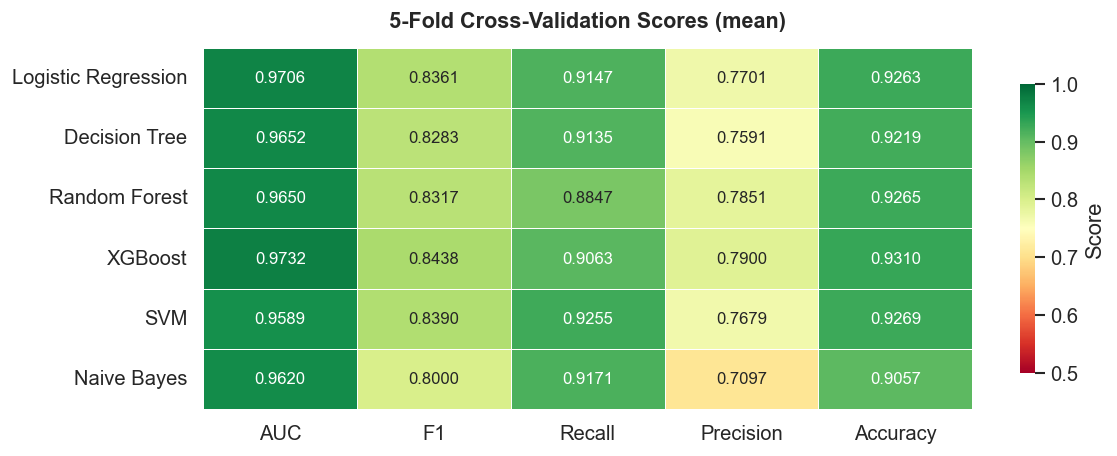

In [6]:
# ── CV results heatmap ─────────────────────────────────────────────────────
cv_mean = pd.DataFrame({
    name: {m: cv_results[name][m].mean() for m in cv_metrics}
    for name in cv_results
}).T
cv_mean.columns = ['AUC', 'F1', 'Recall', 'Precision', 'Accuracy']

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cv_mean, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10}, ax=ax,
            cbar_kws={'label': 'Score', 'shrink': 0.8})
ax.set_title('5-Fold Cross-Validation Scores (mean)', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

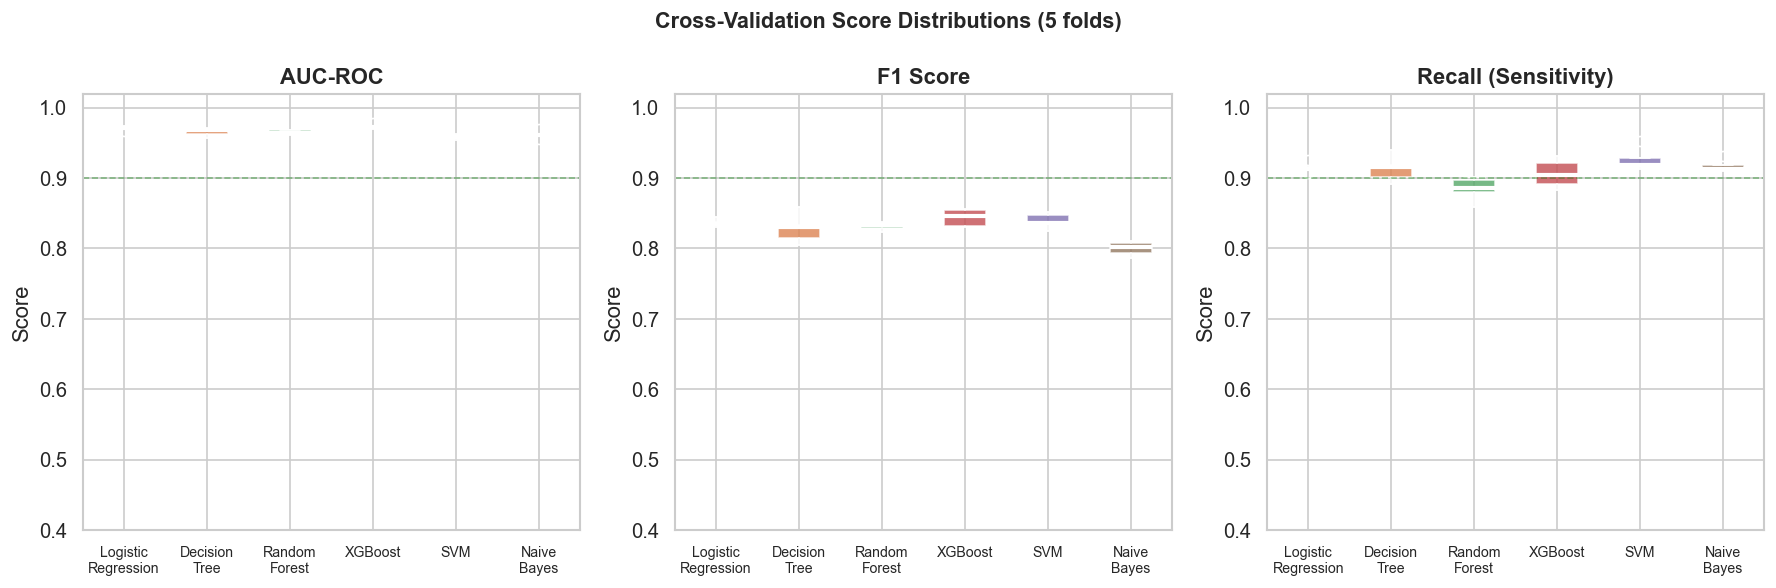

In [7]:
# ── CV score distributions (boxplots) ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_metrics = ['roc_auc', 'f1', 'recall']
titles       = ['AUC-ROC', 'F1 Score', 'Recall (Sensitivity)']
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for ax, metric, title in zip(axes, plot_metrics, titles):
    data  = [cv_results[n][metric] for n in models]
    names = list(models.keys())
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2.5))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels([n.replace(' ',  '\n') for n in names], fontsize=8.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0.4, 1.02)
    ax.axhline(0.9, color='green', linestyle='--', alpha=0.4, linewidth=1)

plt.suptitle('Cross-Validation Score Distributions (5 folds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train on Full Train Set & Evaluate on Test Set

In [8]:
print('Training all models on full training set...\n')
trained_models = {}
test_results   = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred     = pipe.predict(X_test)
    y_proba    = pipe.predict_proba(X_test)[:, 1]
    trained_models[name] = {'pipe': pipe, 'y_pred': y_pred, 'y_proba': y_proba}
    test_results[name] = {
        'AUC':       roc_auc_score(y_test, y_proba),
        'F1':        f1_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Accuracy':  accuracy_score(y_test, y_pred),
    }
    r = test_results[name]
    print(f'{name:22s}  AUC={r["AUC"]:.4f}  F1={r["F1"]:.4f}  '
          f'Recall={r["Recall"]:.4f}  Precision={r["Precision"]:.4f}')

results_df = pd.DataFrame(test_results).T.sort_values('AUC', ascending=False)
print('\nBest model by AUC:', results_df.index[0])

Training all models on full training set...

Logistic Regression     AUC=0.9706  F1=0.8280  Recall=0.8966  Precision=0.7691
Decision Tree           AUC=0.9476  F1=0.8009  Recall=0.9038  Precision=0.7189
Random Forest           AUC=0.9655  F1=0.8147  Recall=0.8822  Precision=0.7567
XGBoost                 AUC=0.9677  F1=0.8160  Recall=0.8846  Precision=0.7572
SVM                     AUC=0.9518  F1=0.8359  Recall=0.9062  Precision=0.7757
Naive Bayes             AUC=0.9582  F1=0.7912  Recall=0.9062  Precision=0.7020

Best model by AUC: Logistic Regression


## 5. ROC Curves & Precision-Recall Curves

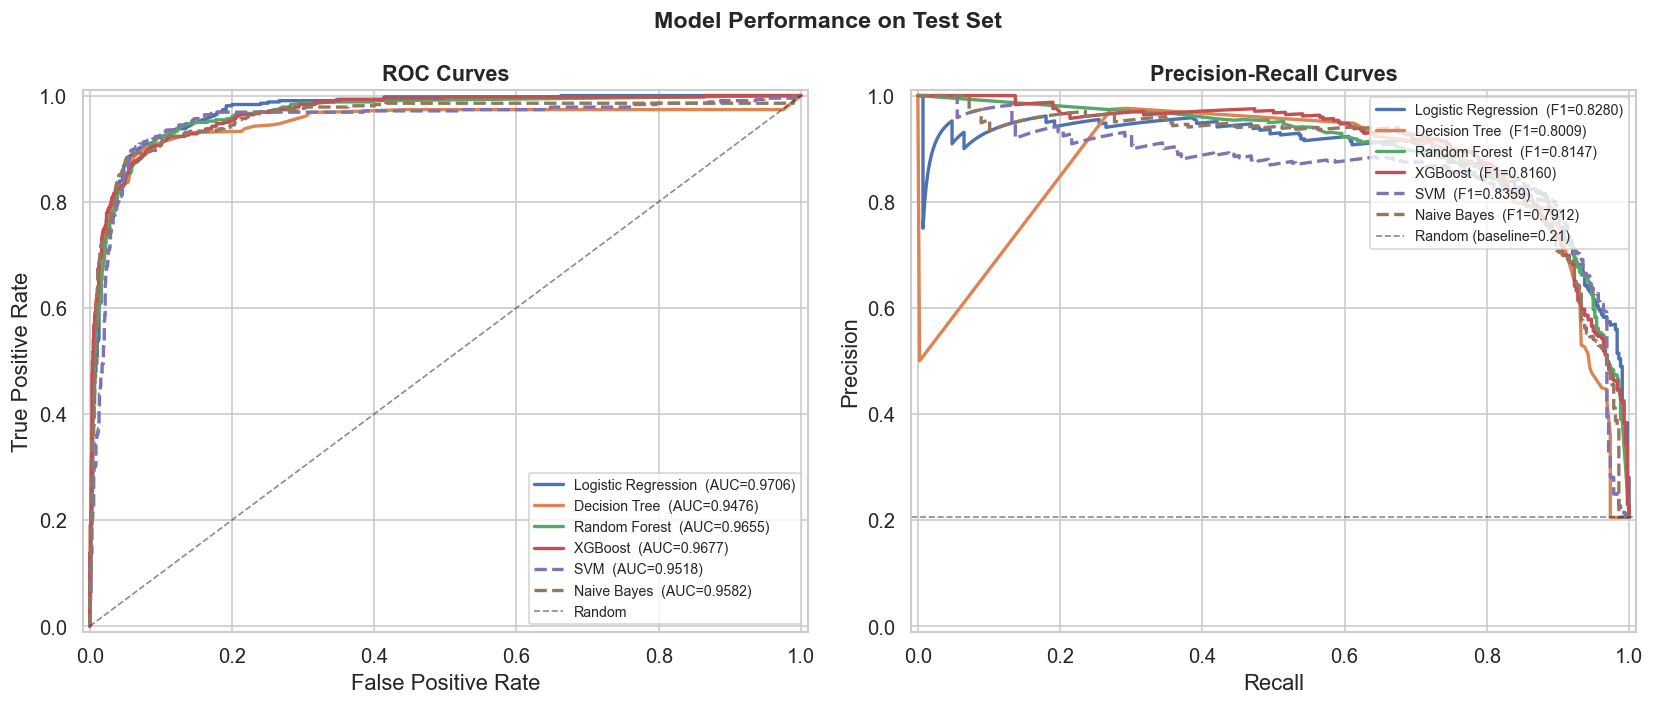

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
line_styles = ['-','-','-','-','--','--']

for (name, res), ls, color in zip(trained_models.items(), line_styles, colors):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc = test_results[name]['AUC']
    axes[0].plot(fpr, tpr, lw=2, linestyle=ls, color=color,
                 label=f"{name}  (AUC={auc:.4f})")
    # PR
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    f1 = test_results[name]['F1']
    axes[1].plot(rec, prec, lw=2, linestyle=ls, color=color,
                 label=f"{name}  (F1={f1:.4f})")

axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=8.5, loc='lower right')
axes[0].set_xlim(-0.01, 1.01); axes[0].set_ylim(-0.01, 1.01)

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, alpha=0.5,
                label=f'Random (baseline={baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=8.5, loc='upper right')
axes[1].set_xlim(-0.01, 1.01); axes[1].set_ylim(-0.01, 1.01)

plt.suptitle('Model Performance on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Confusion Matrices

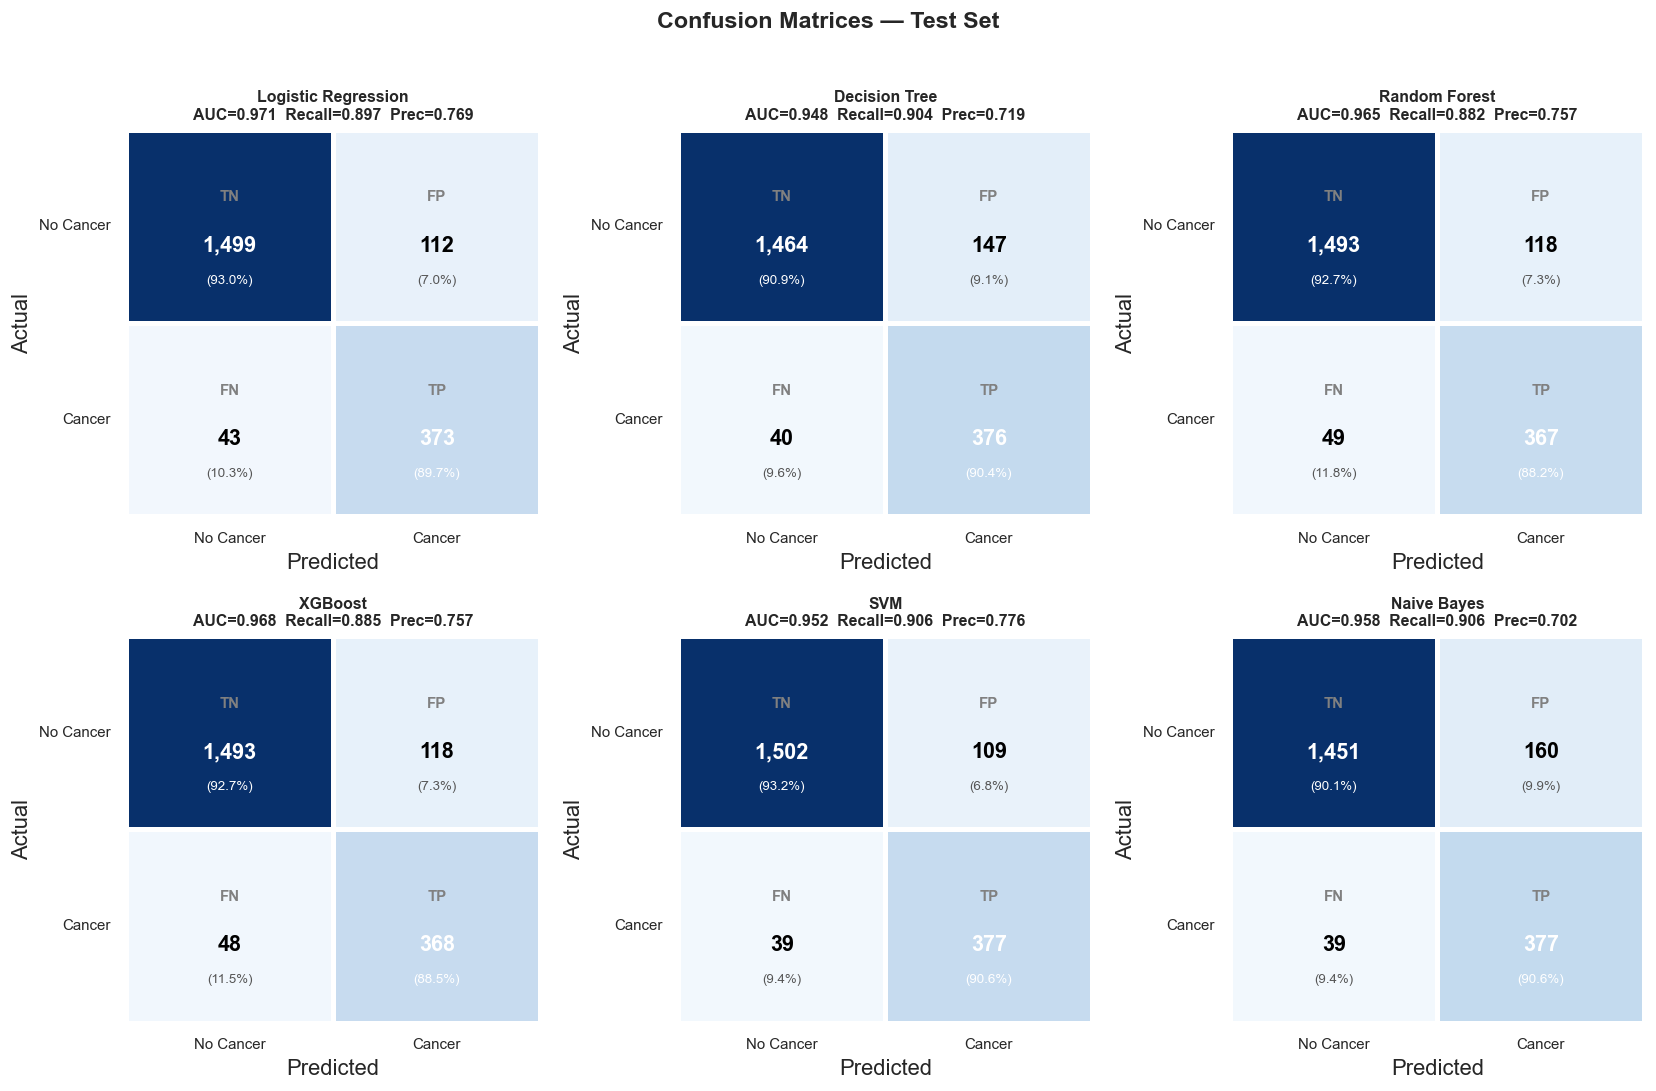

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, (name, res) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=False, fmt='d', ax=ax,
                cmap='Blues', linewidths=2, linecolor='white',
                cbar=False, vmin=0, vmax=cm.max())

    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.35, f'{labels[i][j]}',
                    ha='center', va='center', fontsize=9,
                    color='gray', fontweight='bold')
            ax.text(j+0.5, i+0.6, f'{cm[i,j]:,}',
                    ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if cm_pct[i,j] > 50 else 'black')
            ax.text(j+0.5, i+0.78, f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_pct[i,j] > 50 else '#555')

    r = test_results[name]
    ax.set_title(f"{name}\nAUC={r['AUC']:.3f}  Recall={r['Recall']:.3f}  Prec={r['Precision']:.3f}",
                 fontsize=9.5, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['No Cancer', 'Cancer'], fontsize=9)
    ax.set_yticklabels(['No Cancer', 'Cancer'], fontsize=9, rotation=0)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Metrics Comparison Dashboard

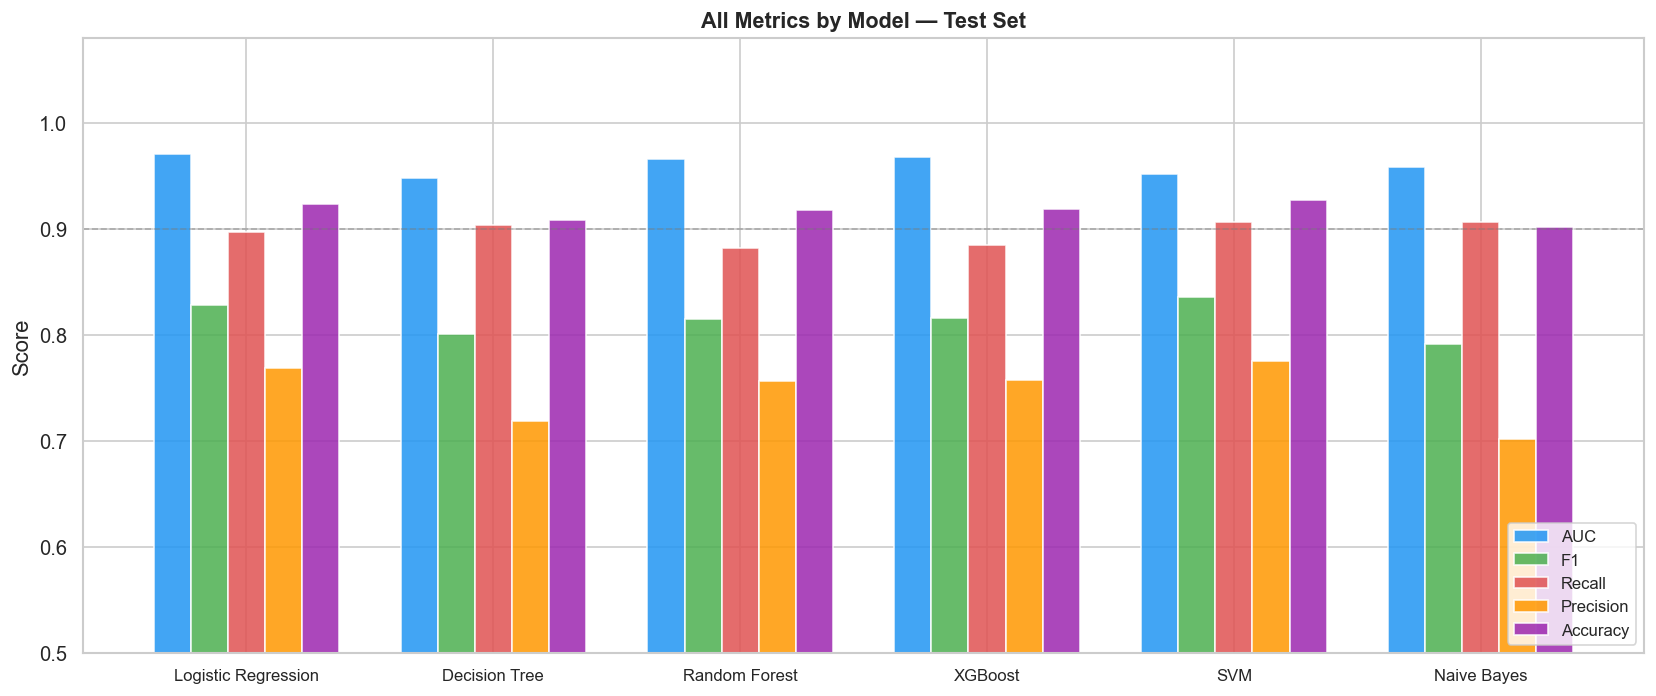


Full results table (sorted by AUC):


,AUC,F1,Recall,Precision,Accuracy
Logistic Regression,0.9706,0.8280,0.8966,0.7691,0.9235
XGBoost,0.9677,0.8160,0.8846,0.7572,0.9181
Random Forest,0.9655,0.8147,0.8822,0.7567,0.9176
Naive Bayes,0.9582,0.7912,0.9062,0.7020,0.9018
SVM,0.9518,0.8359,0.9062,0.7757,0.9270
Decision Tree,0.9476,0.8009,0.9038,0.7189,0.9077


In [11]:
metrics_to_plot = ['AUC', 'F1', 'Recall', 'Precision', 'Accuracy']
x = np.arange(len(models))
width = 0.15
model_names = list(models.keys())

fig, ax = plt.subplots(figsize=(14, 6))
metric_colors = ['#2196F3','#4CAF50','#E05252','#FF9800','#9C27B0']

for i, (metric, mc) in enumerate(zip(metrics_to_plot, metric_colors)):
    vals = [test_results[n][metric] for n in model_names]
    bars = ax.bar(x + i*width, vals, width, label=metric, color=mc, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width*2)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.08)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.legend(loc='lower right', fontsize=10)
ax.set_title('All Metrics by Model — Test Set', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nFull results table (sorted by AUC):')
display(results_df.style.background_gradient(cmap='RdYlGn', vmin=0.5, vmax=1.0).format('{:.4f}'))

## 8. Threshold Tuning (Maximise Recall for Clinical Use)

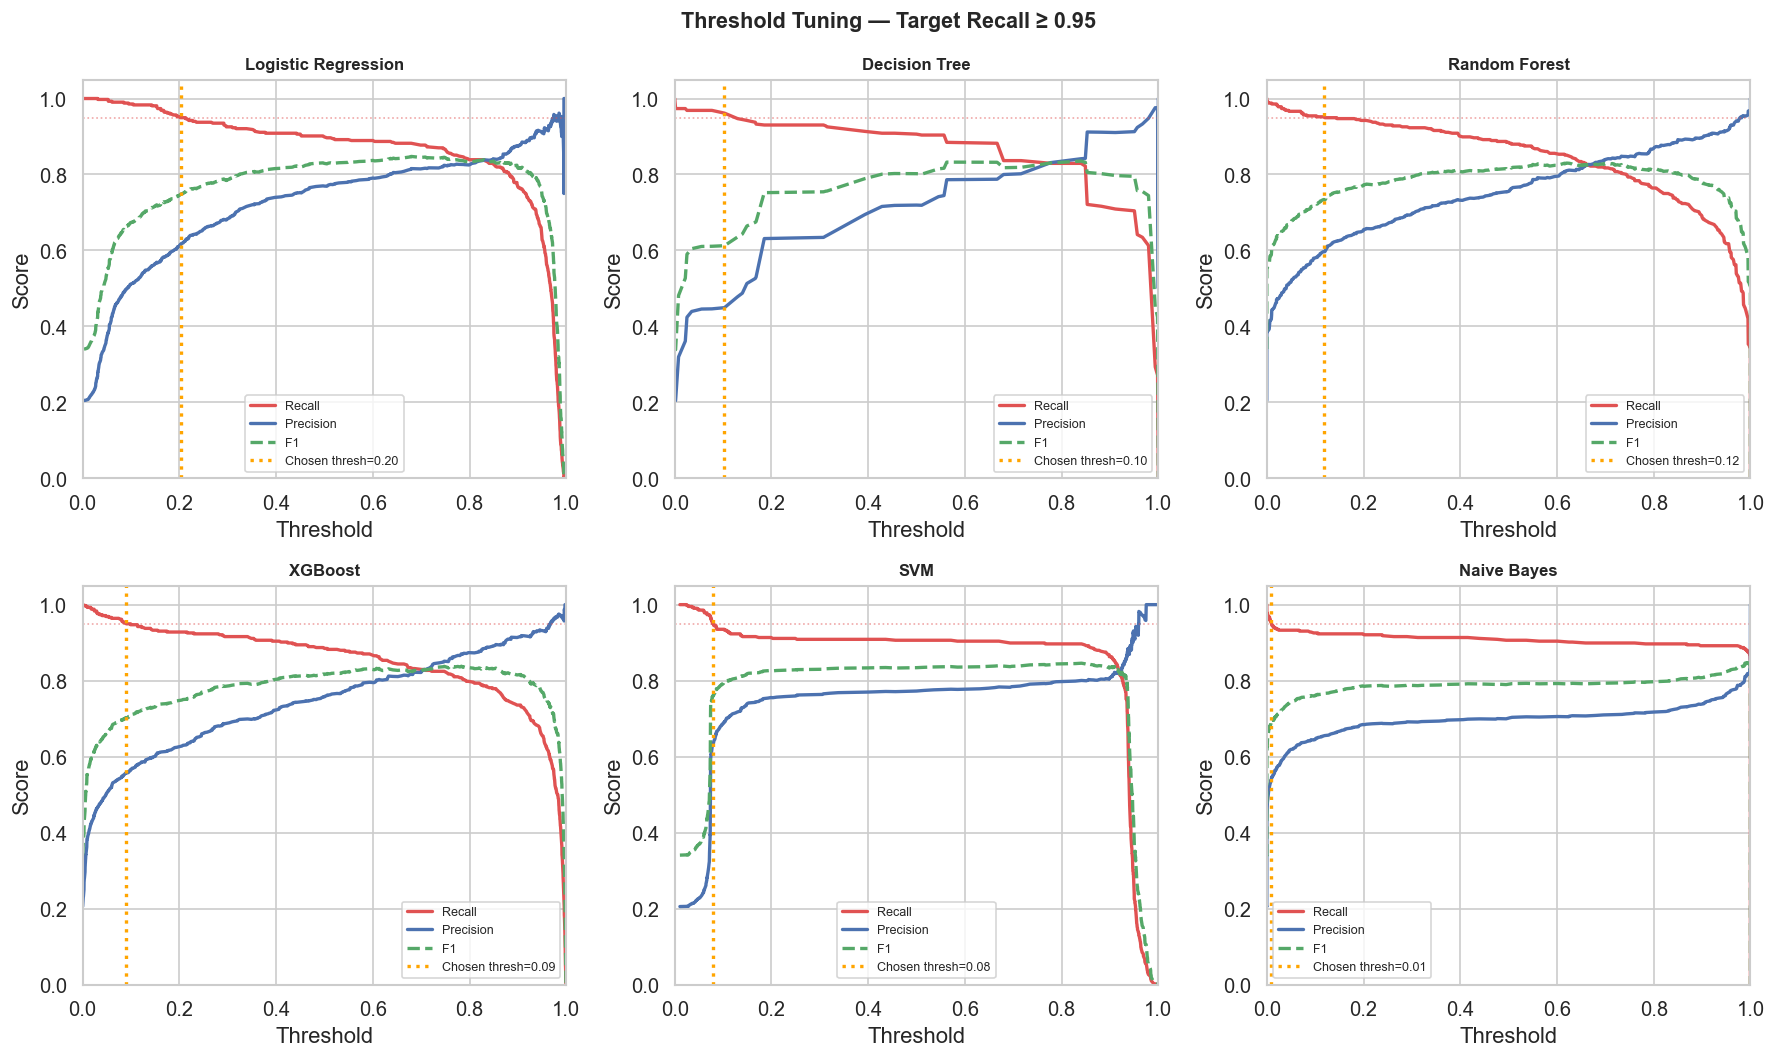


Results after threshold tuning:


,Threshold,Recall,Precision,F1,FN,FP
Logistic Regression,0.202,0.9519,0.6159,0.7479,20,247
Decision Tree,0.103,0.9615,0.4494,0.6126,16,490
Random Forest,0.117,0.9519,0.5973,0.7340,20,267
XGBoost,0.089,0.9519,0.5570,0.7028,20,315
SVM,0.079,0.9519,0.6316,0.7593,20,231
Naive Bayes,0.009,0.9519,0.5395,0.6887,20,338


In [12]:
# For a cancer screening model, we want Recall >= 0.95
# Find threshold per model that achieves this
TARGET_RECALL = 0.95

threshold_results = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, res) in zip(axes, trained_models.items()):
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, res['y_proba'])
    thresholds = np.append(thresh_arr, 1.0)

    # Find lowest threshold giving recall >= TARGET_RECALL
    valid = np.where(rec_arr >= TARGET_RECALL)[0]
    if len(valid) > 0:
        best_idx = valid[np.argmax(prec_arr[valid])]
        best_thresh = thresholds[best_idx]
        best_prec   = prec_arr[best_idx]
        best_rec    = rec_arr[best_idx]
    else:
        best_idx    = np.argmax(rec_arr)
        best_thresh = thresholds[best_idx]
        best_prec   = prec_arr[best_idx]
        best_rec    = rec_arr[best_idx]

    # Apply threshold
    y_pred_tuned = (res['y_proba'] >= best_thresh).astype(int)
    threshold_results[name] = {
        'Threshold': best_thresh,
        'Recall':    recall_score(y_test, y_pred_tuned),
        'Precision': precision_score(y_test, y_pred_tuned),
        'F1':        f1_score(y_test, y_pred_tuned),
        'FN':        confusion_matrix(y_test, y_pred_tuned)[1, 0],
        'FP':        confusion_matrix(y_test, y_pred_tuned)[0, 1],
    }

    ax.plot(thresholds, rec_arr,  color='#E05252', lw=2, label='Recall')
    ax.plot(thresholds, prec_arr, color='#4C72B0', lw=2, label='Precision')
    f1_curve = 2*prec_arr*rec_arr / (prec_arr+rec_arr+1e-9)
    ax.plot(thresholds, f1_curve, color='#55A868', lw=2, linestyle='--', label='F1')
    ax.axvline(best_thresh, color='orange', linestyle=':', lw=2,
               label=f'Chosen thresh={best_thresh:.2f}')
    ax.axhline(TARGET_RECALL, color='#E05252', linestyle=':', lw=1, alpha=0.5)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7.5)

plt.suptitle(f'Threshold Tuning — Target Recall ≥ {TARGET_RECALL}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

thresh_df = pd.DataFrame(threshold_results).T
print('\nResults after threshold tuning:')
display(thresh_df.style.background_gradient(subset=['Recall','Precision','F1'], cmap='RdYlGn').format({
    'Threshold': '{:.3f}', 'Recall': '{:.4f}', 'Precision': '{:.4f}',
    'F1': '{:.4f}', 'FN': '{:.0f}', 'FP': '{:.0f}'
}))

## 9. SHAP Feature Importance (Best Model)

Best model by AUC: Logistic Regression



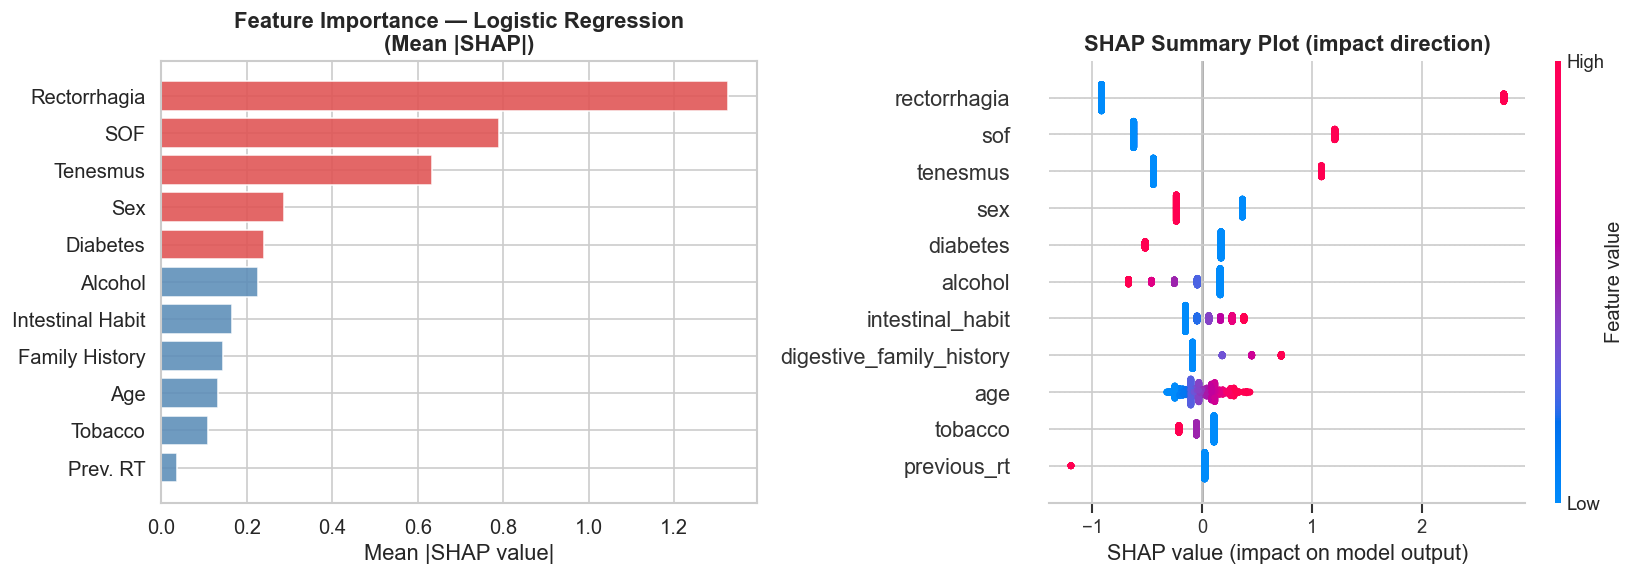

In [13]:
best_model_name = results_df.index[0]
print(f'Best model by AUC: {best_model_name}\n')

best_pipe = trained_models[best_model_name]['pipe']

# Get the classifier step
clf_step = best_pipe.named_steps['clf']

# Transform X_test through the pipeline steps before SHAP
X_test_transformed = X_test.copy()
if 'scaler' in best_pipe.named_steps:
    X_test_transformed = best_pipe.named_steps['scaler'].transform(X_test_transformed)
    X_test_transformed = pd.DataFrame(X_test_transformed, columns=FEATURES)

# SHAP explainer
if best_model_name in ['Random Forest', 'XGBoost', 'Decision Tree']:
    explainer  = shap.TreeExplainer(clf_step)
    shap_vals  = explainer.shap_values(X_test_transformed)
    if isinstance(shap_vals, list):
        sv = shap_vals[1]
    else:
        sv = shap_vals
else:
    explainer = shap.LinearExplainer(clf_step, X_test_transformed)
    sv = explainer.shap_values(X_test_transformed)
    if isinstance(sv, list):
        sv = sv[1]

# Mean absolute SHAP
mean_shap = np.abs(sv).mean(axis=0)
shap_df   = pd.Series(mean_shap, index=FEATURES).sort_values(ascending=True)
feat_labels = {
    'age':'Age','sex':'Sex','sof':'SOF','alcohol':'Alcohol',
    'tobacco':'Tobacco','diabetes':'Diabetes','tenesmus':'Tenesmus',
    'previous_rt':'Prev. RT','rectorrhagia':'Rectorrhagia',
    'intestinal_habit':'Intestinal Habit',
    'digestive_family_history':'Family History'
}
shap_df.index = [feat_labels[i] for i in shap_df.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
bar_colors = ['#E05252' if v > shap_df.median() else '#5B8DB8' for v in shap_df.values]
axes[0].barh(shap_df.index, shap_df.values, color=bar_colors, edgecolor='white', alpha=0.88)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Feature Importance — {best_model_name}\n(Mean |SHAP|)', fontweight='bold')

# SHAP summary beeswarm
plt.sca(axes[1])
shap.summary_plot(sv, X_test_transformed, feature_names=FEATURES,
                  show=False, plot_size=None, color_bar=True,
                  max_display=11)
axes[1].set_title('SHAP Summary Plot (impact direction)', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Final Comparison Summary

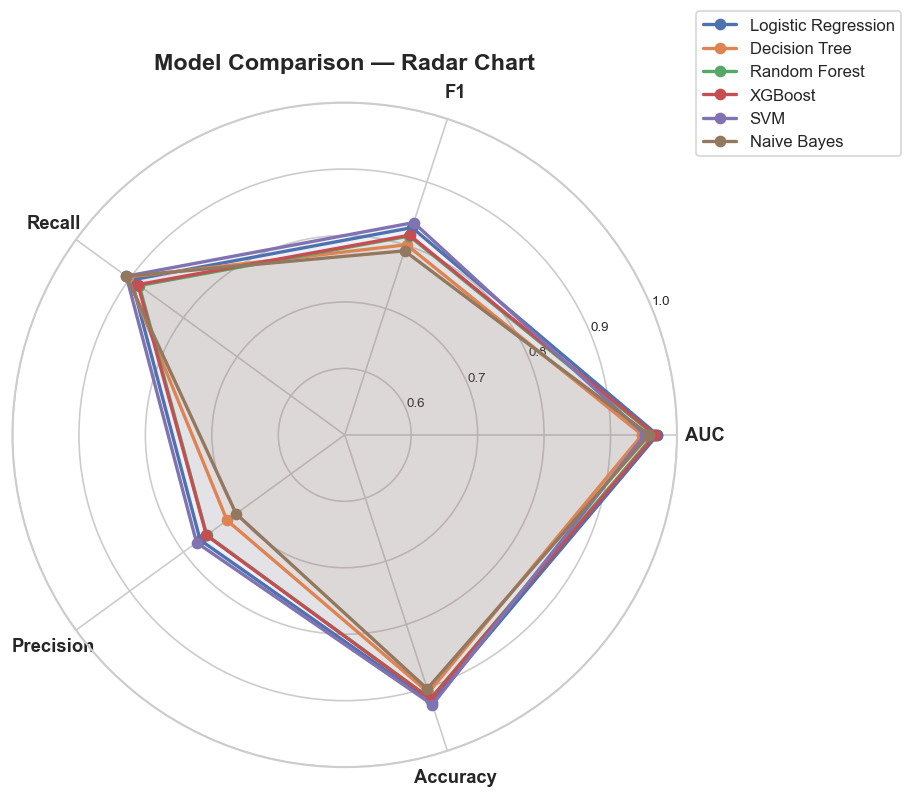

In [14]:
# ── Radar chart ────────────────────────────────────────────────────────────
categories = ['AUC', 'F1', 'Recall', 'Precision', 'Accuracy']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (name, r), color in zip(test_results.items(), colors):
    vals = [r[m] for m in categories] + [r[categories[0]]]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.05, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6','0.7','0.8','0.9','1.0'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('Model Comparison — Radar Chart', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [15]:
# ── Final printed summary ──────────────────────────────────────────────────
print('=' * 72)
print('                    FINAL MODEL COMPARISON SUMMARY')
print('=' * 72)
print(f'{"Model":<22} {"AUC":>7} {"F1":>7} {"Recall":>9} {"Prec":>8} {"Acc":>8}')
print('-' * 72)
for name in results_df.index:
    r = test_results[name]
    best = ' ◄ BEST AUC' if name == results_df.index[0] else ''
    print(f'{name:<22} {r["AUC"]:>7.4f} {r["F1"]:>7.4f} {r["Recall"]:>9.4f} {r["Precision"]:>8.4f} {r["Accuracy"]:>8.4f}{best}')
print('=' * 72)
print()
print('AFTER THRESHOLD TUNING (target recall >= 0.95):')
print(f'{"Model":<22} {"Threshold":>10} {"Recall":>8} {"Prec":>8} {"F1":>7} {"FN":>5} {"FP":>6}')
print('-' * 72)
for name in thresh_df.index:
    t = thresh_df.loc[name]
    print(f'{name:<22} {t["Threshold"]:>10.3f} {t["Recall"]:>8.4f} {t["Precision"]:>8.4f} {t["F1"]:>7.4f} {int(t["FN"]):>5} {int(t["FP"]):>6}')
print('=' * 72)
print('FN = False Negatives (missed cancers) — minimise this!')
print('FP = False Positives (unnecessary alarms)')

                    FINAL MODEL COMPARISON SUMMARY
Model                      AUC      F1    Recall     Prec      Acc
------------------------------------------------------------------------
Logistic Regression     0.9706  0.8280    0.8966   0.7691   0.9235 ◄ BEST AUC
XGBoost                 0.9677  0.8160    0.8846   0.7572   0.9181
Random Forest           0.9655  0.8147    0.8822   0.7567   0.9176
Naive Bayes             0.9582  0.7912    0.9062   0.7020   0.9018
SVM                     0.9518  0.8359    0.9062   0.7757   0.9270
Decision Tree           0.9476  0.8009    0.9038   0.7189   0.9077

AFTER THRESHOLD TUNING (target recall >= 0.95):
Model                   Threshold   Recall     Prec      F1    FN     FP
------------------------------------------------------------------------
Logistic Regression         0.202   0.9519   0.6159  0.7479    20    247
Decision Tree               0.103   0.9615   0.4494  0.6126    16    490
Random Forest               0.117   0.9519   0.5973  0.

See that svm has better recall (most sensitive) and a better F1 than Naive Bayes.